### Instruction Fine-Tuning
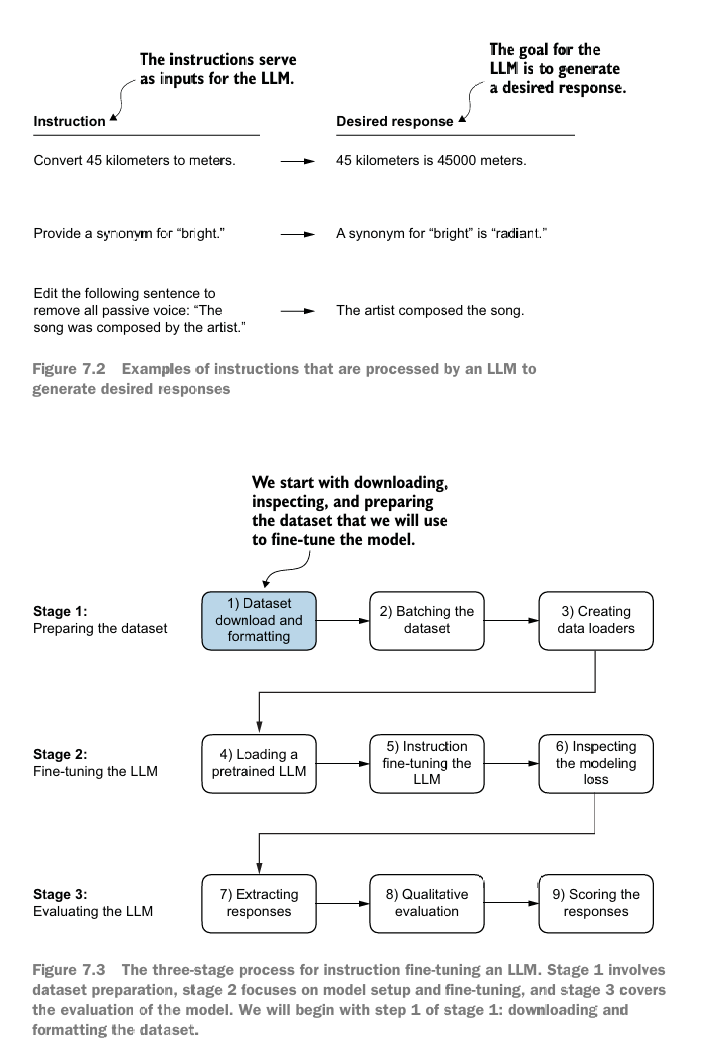

In [1]:
from importlib.metadata import version

pkgs = [
    "numpy",       # PyTorch & TensorFlow dependency
    "matplotlib",  # Plotting library
    "tiktoken",    # Tokenizer
    "torch",       # Deep learning library
    "tqdm",        # Progress bar
    "tensorflow",  # For OpenAI's pretrained weights
]
for p in pkgs:
    print(f"{p} version: {version(p)}")

numpy version: 2.4.6
matplotlib version: 3.11.1
tiktoken version: 0.13.0
torch version: 2.13.0
tqdm version: 4.69.1
tensorflow version: 2.21.0


In [2]:
# -- Dataset download
import json
import os
import requests


def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        text_data = response.text
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data


# The book originally used the following code below
# However, urllib uses older protocol settings that
# can cause problems for some readers using a VPN.
# The `requests` version above is more robust
# in that regard.

"""
import urllib

def download_and_load_file(file_path, url):

    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    else:
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data
"""


file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


In [3]:
print("Example entry:\n", data[50])

print("Another example entry:\n", data[999])

Example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}
Another example entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


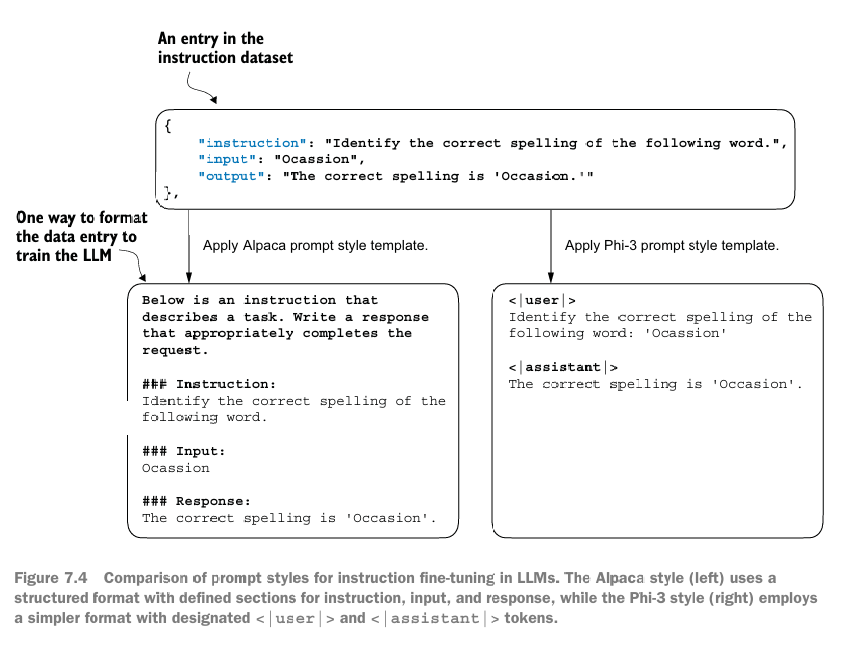

- Various methods to format the entries for LLM
- One such way is the Alpaca style
- Another is the Phi-3 style (right)

In [4]:
# =-- Implementing promp formatting 
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

In [5]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


Splitting data into training, validation and test...

In [6]:
train_portion = int(len(data) * 0.85)  # 85% for training
test_portion = int(len(data) * 0.1)    # 10% for testing
val_portion = len(data) - train_portion - test_portion  # Remaining 5% for validation

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

print("Training set length: ", len(train_data))
print("Validation set length: ", len(val_data))
print("Test set length: ", len(test_data))

Training set length:  935
Validation set length:  55
Test set length:  110


### Organizing data into training batches
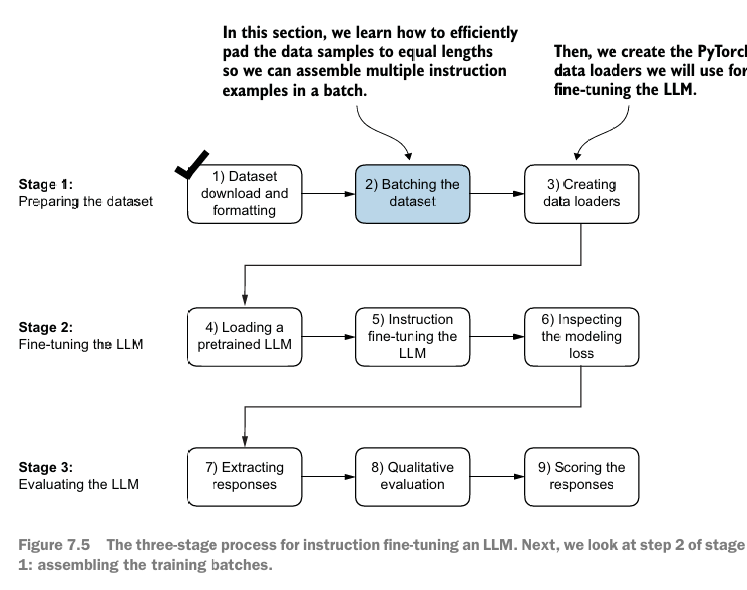

Five sub-steps of the Batching process:
- Interestingly has a `-100` padding token to exclude from the training loss

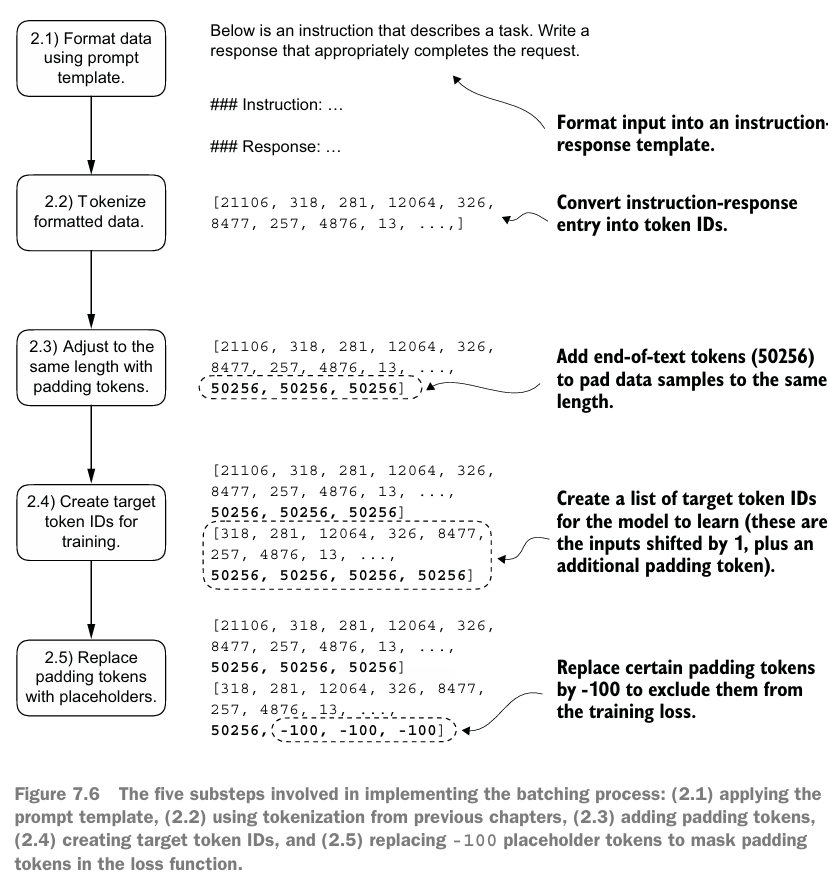


Steps 2.1 and 2.2 implements the batching process. Batching process is described below:

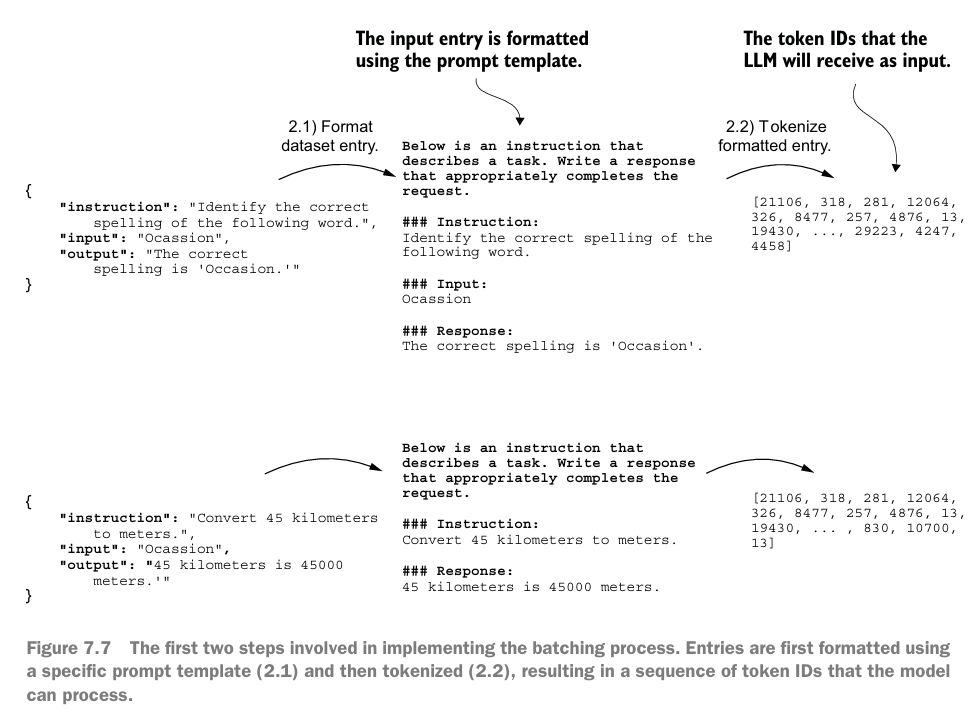

In [7]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []

        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text

            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)



In [8]:
# Instead of appending <|endoftext|> tokens to text inputs,
# we can append token ID corresponding to <|endoftext|> to pretokenize
# inputs directly.
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

print("<|endoftext|> token id is:")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

<|endoftext|> token id is:
[50256]


Step 2.3:
- We have a develop custom collate function that pads training examples in each batch to the same length, while allowing different batches to have different lengths
- Each batch may have different lenghts!
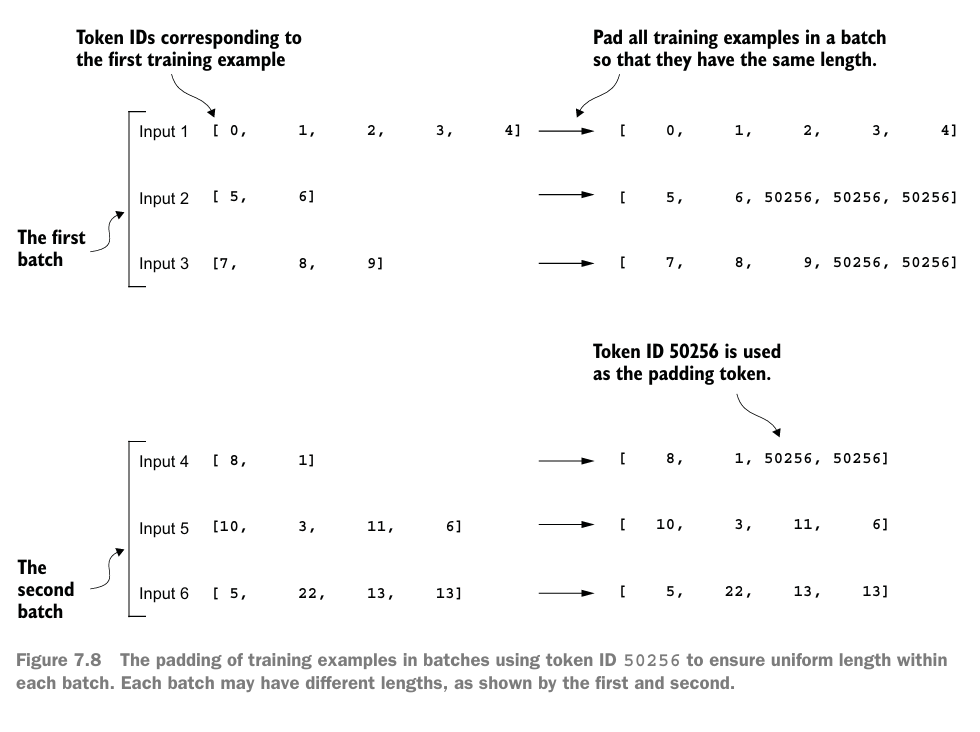

In [9]:
# Custp, collate designed to be integrated into Pytorch DataLoader
def custom_collate_draft_1(
        batch,
        pad_token_id=50256,
        device="cpu"):
    # Find longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst = []

    # Pads and prepares inputs
    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]      # Add extra padded token

        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  # Removes extra padded token
        inputs_lst.append(inputs)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor


In [10]:
# Testing collate function
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

# Resulting batch
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


- all inputs have been padded to length of longest input list

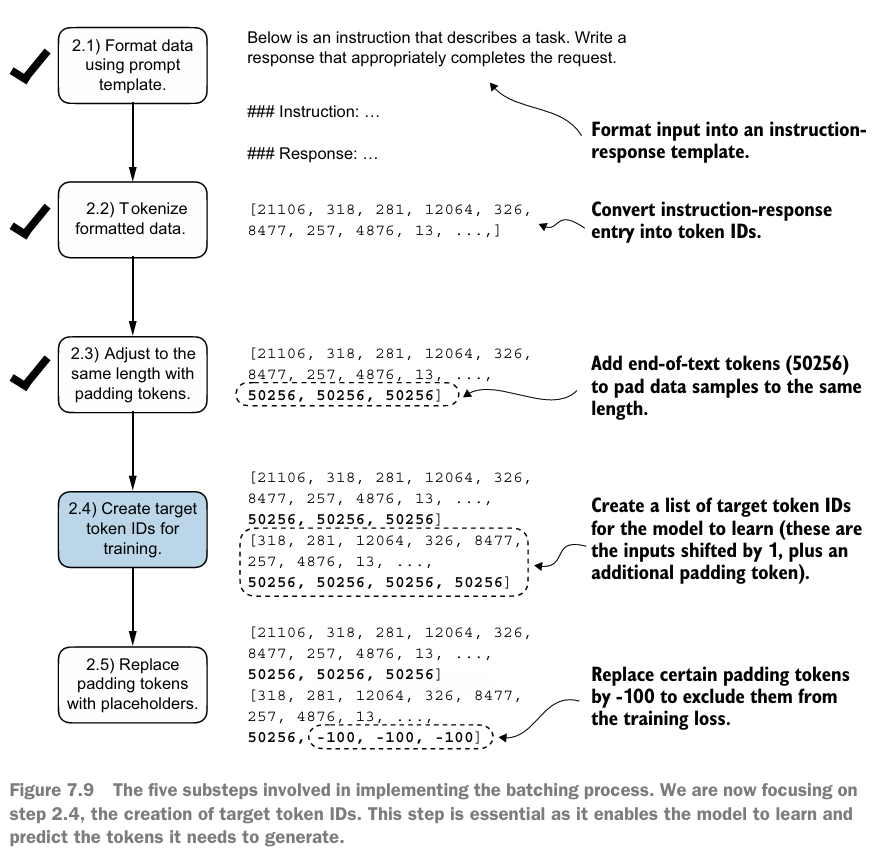
- Need to create batches with target token IDs corresponding to batch of input IDs
- The target token IDs will be the inputs shifted by 1 + additional padding token

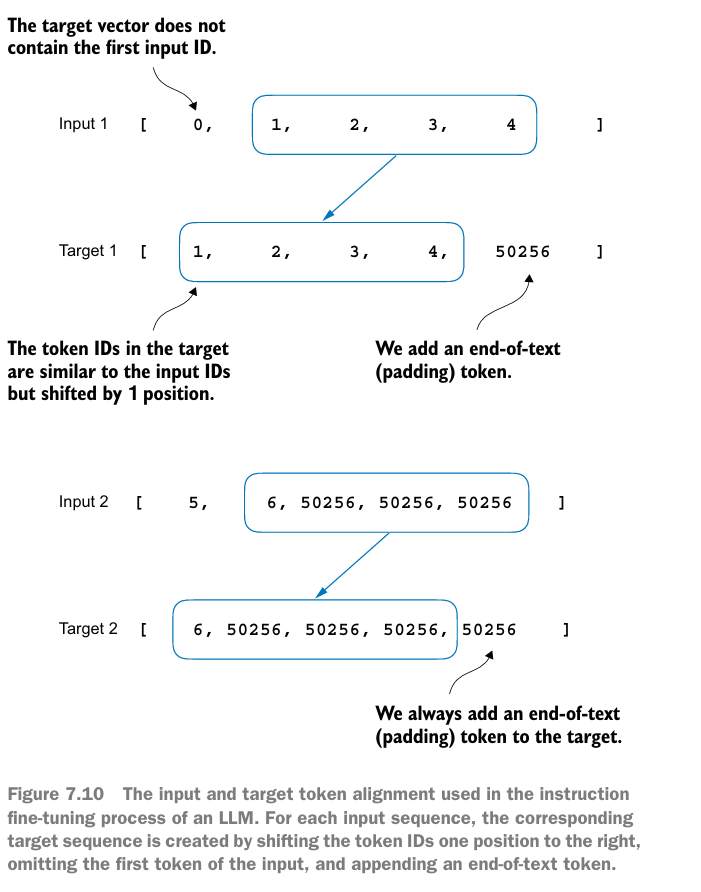

In [11]:
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]      # Add extra padded token

        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
        )

        # Truncates last token for inputs
        inputs = torch.tensor(padded[:-1])
        # Shifts +1 to the right for tagets
        targets = torch.tensor(padded[1:])

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [12]:
# Testing collate function 2
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

# Resulting batch
inputs, targets = custom_collate_draft_2(batch) 
print("Inputs:\n", inputs)
print("Targets:\n", targets)

Inputs:
 tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
Targets:
 tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


Next step:

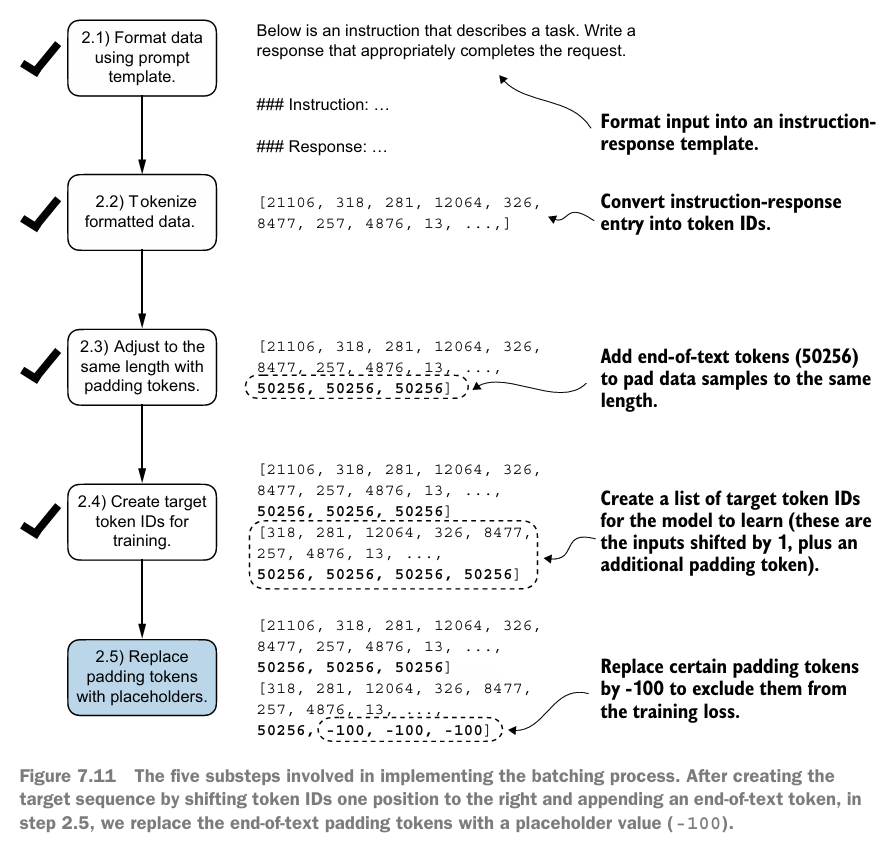

- Assign -100 to all padding tokens. This special value ensures that only meaninful data influences the model learning as the padding tokens with -100 are excluding from contributing the training loss
- Note that one 50256 token ID is still retained to allow LLM to learn when to generate end of text token. This is used to indicate the generate response is complete

Desired:

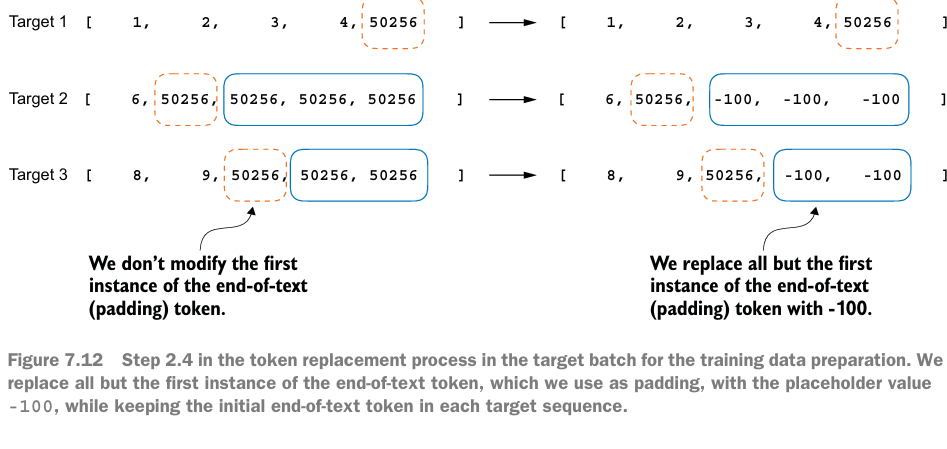

In [13]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]      # Add extra padded token

        # Pad sequences to max length
        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
        )

        # Truncates last token for inputs
        inputs = torch.tensor(padded[:-1])
        # Shifts +1 to the right for tagets
        targets = torch.tensor(padded[1:])

        # Replaces all but the first padding tokens in targets
        # by ignore index
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # Optionally truncates to max sequence length
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

In [14]:
# Testing collate function
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

# Resulting batch
inputs, targets = custom_collate_fn(batch) 
print("Inputs:\n", inputs)
print("Targets:\n", targets)

Inputs:
 tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
Targets:
 tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


- Note that default setting of cross entropy func in Pytorch is `cross_entropy(..., ignore_index=-100)`, meaning targets labelled with -100 is ignored.
- One 50256 is kept in targets to help LLM learn to generate end-of-text 

In [15]:
# -- A look on losses and -100
logits_1 = torch.tensor(
    [[-1.0, 1.0],  # 1st training example
     [-0.5, 1.5]]  # 2nd training example
)
targets_1 = torch.tensor([0, 1])


loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


In [16]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]  # New 3rd training example
)
targets_2 = torch.tensor([0, 1, 1])

loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


In [17]:
# NOTE: The -100 token cause the loss to be similar to the first logits_1! 
# It didn't have an impact unlike the logits_2 example.
targets_3 = torch.tensor([0, 1, -100])

loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


It is also common to mask out target token IDs that correspond to instruction
- Allows model to focus on generating accurate responses rather than memorizing instructions. This can help with overfitting!
- Not implemented for now.. (this will be an exercise to do later!)

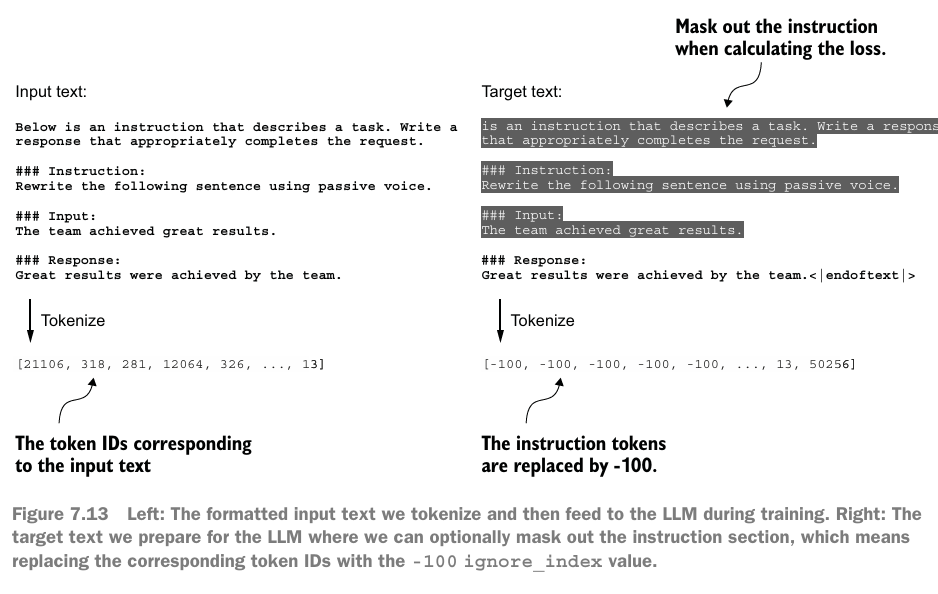

In [18]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: cuda


In [19]:
from functools import partial

customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024,
)

- Instantiating dataloaders
- `collate_fn` callback function in Dataloader defines how to merge individual data samples into a single mini-batch
- `drop_last` determines whether to discard final incomplete batch if total datasize is not divisble by chosen batch-size

In [20]:
from torch.utils.data import DataLoader

torch.manual_seed(123)
num_workers = 0
batch_size = 8

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

In [21]:
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [22]:
# -- Testing dimensions
print("Train Loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train Loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.

- Notice that the dimensions are `batch_size x sequence_length`. `sequence_length` varies! 

In [23]:
# -- Checking targets for -100
print(targets[0])

tensor([  318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,   257,
         2882,   326, 20431, 32543,   262,  2581,    13,   198,   198, 21017,
        46486,    25,   198, 30003,  6525,   262,  6827,  1262,   257,   985,
          576,    13,   198,   198, 21017, 23412,    25,   198,   464,  5156,
          318,   845, 13779,    13,   198,   198, 21017, 18261,    25,   198,
          464,  5156,   318,   355, 13779,   355,   257,  4936,    13, 50256,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100],
       device='cuda:0')


### Loading a pretrained LLM

In [38]:
# -- Fix relative import to get gpt package
import os, sys
parent_dir = os.path.abspath('..')
# the parent_dir could already be there if the kernel was not restarted,
# and we run this cell again
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# -- Package imports
import tiktoken
from importlib.metadata import version

pkgs = ["matplotlib",  # Plotting library
        "numpy",       # PyTorch & TensorFlow dependency
        "tiktoken",    # Tokenizer
        "torch",       # Deep learning library
        "tensorflow",  # For OpenAI's pretrained weights
        "pandas"       # Dataset loading
       ]
for p in pkgs:
    print(f"{p} version: {version(p)}")
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

from gpt.gpt_download import download_and_load_gpt2
from gpt.gpt_utils import load_weights_into_gpt
from gpt.gpt_utils import (
    generate,
    generate_text_simple,
    text_to_token_ids,
    token_ids_to_text
)
from gpt.gpt_model import GPTModel

matplotlib version: 3.11.1
numpy version: 2.4.6
tiktoken version: 0.13.0
torch version: 2.13.0
tensorflow version: 2.21.0
pandas version: 3.0.5


In [25]:
# -- Loading model similar to previous chapters
BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# CHOOSE_MODEL = "gpt2-medium (355M)"
CHOOSE_MODEL = "gpt2-xl (1558M)"

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="../gpt/gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

File already exists and is up-to-date: ../gpt/gpt2/1558M/checkpoint
File already exists and is up-to-date: ../gpt/gpt2/1558M/encoder.json
File already exists and is up-to-date: ../gpt/gpt2/1558M/hparams.json
File already exists and is up-to-date: ../gpt/gpt2/1558M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: ../gpt/gpt2/1558M/model.ckpt.index
File already exists and is up-to-date: ../gpt/gpt2/1558M/model.ckpt.meta
File already exists and is up-to-date: ../gpt/gpt2/1558M/vocab.bpe


In [26]:
# -- Testing model on an example
torch.manual_seed(123)
input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [29]:
token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)
print(generated_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Response:

The chef cooks the meal every day.

### Response:

The chef cooks the meal every day.

### Response:


In [31]:
response_text = (
    generated_text[len(input_text):]
    .replace("### Response:", "")
    .strip()
)
print(response_text)

The chef cooks the meal every day.



The chef cooks the meal every day.


### Finetuning LLM on instruction data

In [39]:
# TODO: Put in gpt_utils
# -- Loss funcs
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

# -- Training funcs
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
        decoded_text = token_ids_to_text(token_ids, tokenizer)
        print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()


def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()  # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()  # Calculate loss gradients
            optimizer.step()  # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen

# -- Plot utils

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

In [34]:
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.549334096908569
Validation loss: 3.462373876571655


- Training time!

In [37]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.016, Val loss 2.057
Ep 1 (Step 000005): Train loss 0.904, Val loss 0.828
Ep 1 (Step 000010): Train loss 0.678, Val loss 0.785
Ep 1 (Step 000015): Train loss 0.707, Val loss 0.755
Ep 1 (Step 000020): Train loss 0.620, Val loss 0.753
Ep 1 (Step 000025): Train loss 0.667, Val loss 0.738
Ep 1 (Step 000030): Train loss 0.662, Val loss 0.722
Ep 1 (Step 000035): Train loss 0.616, Val loss 0.700
Ep 1 (Step 000040): Train loss 0.553, Val loss 0.689
Ep 1 (Step 000045): Train loss 0.500, Val loss 0.672
Ep 1 (Step 000050): Train loss 0.500, Val loss 0.654
Ep 1 (Step 000055): Train loss 0.616, Val loss 0.643
Ep 1 (Step 000060): Train loss 0.580, Val loss 0.630
Ep 1 (Step 000065): Train loss 0.536, Val loss 0.635
Ep 1 (Step 000070): Train loss 0.442, Val loss 0.628
Ep 1 (Step 000075): Train loss 0.451, Val loss 0.621
Ep 1 (Step 000080): Train loss 0.446, Val loss 0.610
Ep 1 (Step 000085): Train loss 0.377, Val loss 0.598
Ep 1 (Step 000090): Train loss 0.414, Val loss

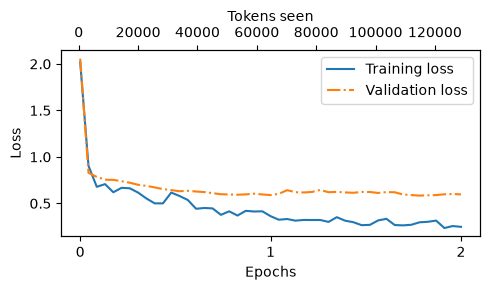

In [40]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

Generating responses

In [43]:
torch.manual_seed(123)

for entry in test_data[:3]:
    input_text = format_input(entry)
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)

    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-----------------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car raced down the road.
-----------------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> A thunderstorm is typically associated with clouds, rain, and snow.
-----------------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author o

- Model performs relatively well
- Answers to first and last instructions are clearly correct

In [44]:
# -- Saving the model for future use
import re

file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

# -- Load model via
# model.load_state_dict(torch.load("gpt2-medium355M-sft.pth"))

Model saved as gpt2-xl1558M-sft.pth


#### Model Evaluation
LLMs such as chatbots evaluated via multiple approaches:
- short-answer and multiple-choice benchmarks such as Measuring Massive Multitask Lanaguge Understanding (MMLU)
- Human preference comparison to other LLMS
- Automated conversational benchmarks, in where another LLM is used to evaluate responses

Human eval can be laborious and time-consuming. Can use another LLM to assess quality of generated responses. Trying an approach inspired by AlpacaEval...

In [66]:
# -- Load the model
model = GPTModel(BASE_CONFIG)
model.load_state_dict(torch.load("gpt2-xl1558M-sft.pth"))
model.to(device)


GPTModel(
  (tok_emb): Embedding(50257, 1600)
  (pos_emb): Embedding(1024, 1600)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1600, out_features=1600, bias=True)
        (W_key): Linear(in_features=1600, out_features=1600, bias=True)
        (W_value): Linear(in_features=1600, out_features=1600, bias=True)
        (out_proj): Linear(in_features=1600, out_features=1600, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1600, out_features=6400, bias=True)
          (1): GELU()
          (2): Linear(in_features=6400, out_features=1600, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (dropout_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linea

In [67]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    input_text = format_input(entry)
    # print(input_text)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)

    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )
    test_data[i]["model_response"] = response_text

with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)     # ident for pretty-printing

100%|██████████| 110/110 [03:00<00:00,  1.64s/it]


In [68]:
# Check test data with response
print(test_data[4])

{'instruction': 'Correct the punctuation in the sentence.', 'input': 'Its time to go home.', 'output': "The corrected sentence should be: 'It's time to go home.'", 'model_response': 'Its time to go home.'}


#### Evaluating fine-tuned LLM

In [69]:
# -- Check if Ollama session is running properly to eval test set responses
import psutil

def check_if_running(process_name):
    running = False
    for proc in psutil.process_iter(["name"]):
        if process_name in proc.info["name"]:
            running = True
            break
    return running

ollama_running = check_if_running("ollama")
if not ollama_running:
    print("Ollama not running. Launch ollama before proceeding")
print("ollama_running:", check_if_running("ollama"))

ollama_running: True


In [70]:
# -- Querying a local Ollama model
import urllib.request

def query_model(
    prompt,
    model="llama3",
    url="http://localhost:11434/api/chat"
):
    # Data payload as a dictionary
    data = {
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        # Set deterministic responses
        "options": {
            "seed": 123,
            "temperature": 0,
            "num_ctx": 2048
        }
    }

    # Converts dict to a JSON formatted string and encodes
    # it to bytes
    payload = json.dumps(data).encode("utf-8")

    # Creates a request object setting method to POST
    # and adding necessary headers
    request = urllib.request.Request(
        url,
        data=payload,
        method="POST"
    )
    request.add_header("Content-Type", "application/json")

    # Sends the request and captures the response
    response_data = ""
    with urllib.request.urlopen(request) as response:
        while True:
            line = response.readline().decode("utf-8")
            if not line:
                break
            response_json = json.loads(line)
            response_data += response_json["message"]["content"]
    return response_data


In [71]:
# Testing llama3 query
model = "llama3"
result = query_model("What do Llamas eat?", model)
print(result)

Llamas are herbivores, which means they primarily feed on plant-based foods. Their diet typically consists of:

1. Grasses: Llamas love to graze on various types of grasses, including tall grasses, short grasses, and even weeds.
2. Hay: High-quality hay, such as alfalfa or timothy hay, is a staple in a llama's diet. They enjoy munching on hay cubes or loose hay.
3. Grains: Llamas may receive grains like oats, barley, or corn as part of their diet. However, these should be given in moderation to avoid digestive issues.
4. Fruits and vegetables: Llamas can benefit from occasional treats like fruits (e.g., apples, carrots) and vegetables (e.g., sweet potatoes, broccoli). These should be introduced gradually to ensure they don't cause digestive upset.
5. Minerals: Llamas need access to mineral supplements, such as salt licks or loose minerals, to ensure they're getting essential nutrients.

Some interesting facts about llama eating habits:

* Llamas are ruminants, which means they have a f

- Using `query_model` we can eval response generated by fine-tuned model

In [72]:
for entry in test_data[:3]:
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score. " 
    )
    print("\nDataset response:")
    print(">>", entry['output'])
    print("\nModel response:")
    print(">>", entry['model_response'])
    print("\nScore:")
    print(">>", query_model(prompt))
    print("\n-------------------------")


Dataset response:
>> The car is as fast as lightning.

Model response:
>> The car raced down the road.

Score:
>> I'd rate the model response "The car raced down the road." a score of 20 out of 100.

Here's why:

* The original instruction was to rewrite the sentence using a simile, which means creating a comparison between two unlike things using "like" or "as". The input sentence "The car is very fast." was rewritten as "The car is as fast as lightning.", which is a perfect example of a simile.
* In contrast, the model response "The car raced down the road." does not use a simile at all. It's a simple statement that describes the action of the car, but it doesn't create a comparison between two unlike things.

Therefore, I would score this response as 20 out of 100, indicating that it only partially addresses the original instruction and does not provide a rewritten sentence using a simile.

-------------------------

Dataset response:
>> The type of cloud typically associated with 

In [73]:
# -- LLM Model Evaluation Function
def generate_model_scores(json_data, json_key, model="llama3"):
    scores = []

    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry['model_response']}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
            f"Respond with the integer number only." 
        )

        score = query_model(prompt, model)
        try:
            scores.append(int(score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue
    return scores

In [74]:
scores = generate_model_scores(test_data, "model_response")
print(f"Number of scores: {len(scores)} of {len(test_data)}")
print(f"Average score: {sum(scores)/len(scores):.2f}\n")

Scoring entries: 100%|██████████| 110/110 [00:28<00:00,  3.88it/s]

Number of scores: 110 of 110
Average score: 51.05



To further improve model's peformance we can explore strategies such as:
- Adjust hyper params during fine-tuning. (i.e learning rate, batch size, number of epochs)
- Increasing size of training dataset or diversifying examples
- Experiment with different prompts or instruction formats
- Use larger pretrained model

#### Parameter-efficient fine-tuning with LoRA
Exercise 7.4